In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('Placement.csv')

In [4]:
df

,cgpa,iq,placement
0,8.1,110,Yes
1,7.2,105,No
2,6.5,120,Yes
3,9.0,130,Yes
4,7.8,115,No
...,...,...,...
206,7.6,107,No
207,8.7,120,Yes
208,6.4,94,No
209,7.8,110,Yes


In [6]:
df['placement'] = df['placement'].apply(lambda x: 1 if x == 'Yes' else 0)

,cgpa,iq,placement
0,8.1,110,1
1,7.2,105,0
2,6.5,120,1
3,9.0,130,1
4,7.8,115,0
...,...,...,...
206,7.6,107,0
207,8.7,120,1
208,6.4,94,0
209,7.8,110,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211 entries, 0 to 210
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       211 non-null    float64
 1   iq         211 non-null    int64  
 2   placement  211 non-null    int64  
dtypes: float64(1), int64(2)
memory usage: 5.1 KB


In [26]:
df['placement'].value_counts()

,count
placement,
1,122
0,89


In [8]:
df.describe()

,cgpa,iq,placement
count,211.000000,211.000000,211.000000
mean,7.700474,112.649289,0.578199
std,1.009974,12.467109,0.495021
min,6.000000,90.000000,0.000000
25%,6.800000,102.000000,0.000000
50%,7.700000,112.000000,1.000000
75%,8.600000,122.000000,1.000000
max,9.400000,139.000000,1.000000


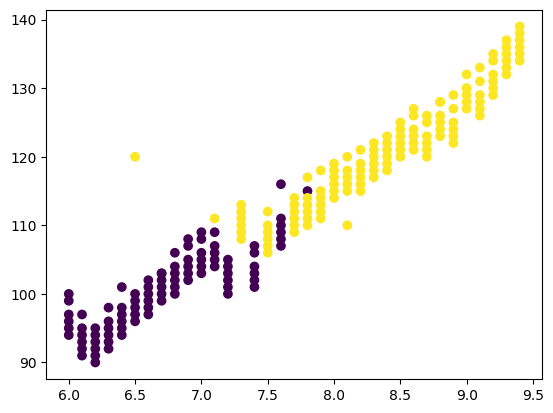

In [9]:
import matplotlib.pyplot as plt

plt.scatter(df['cgpa'], df['iq'],c=df['placement'])

In [10]:
X = df[['cgpa','iq']]
y = df['placement']

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [22]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [23]:
y_pred = model.predict(X_test)

In [27]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)*100

95.3125

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


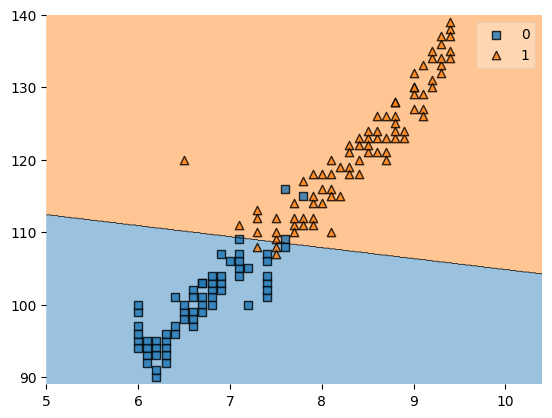

In [25]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_train.values, y_train.values, clf=model)
plt.show()